# LLM

---

Цель работы: обучить Byte-level BPE токенизатор и небольшую LM.  

Несколько последовательных блоков: реализация и обучение токенизатора, реализация Transformer модели и обучение модели на датасете с русскими анекдотами!

In [1]:
# Установим необходимые дополнительные библиотеки

%pip install --quiet datasets livelossplot

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 627.3/627.3 kB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 42.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.6/155.6 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 5.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires ipython==7.34.0, but you have ipython 9.13.0 which is incompatible.
moviepy 1.0.3 requires decorator<5.0,>=4.0.2, but you have decorator 5.3.1 which is incompatible.


In [2]:
# Необходимые импорты

import inspect
import json
import os
from collections import Counter
from dataclasses import dataclass
from functools import lru_cache, partial
from pathlib import Path

import regex as re
import torch
import torch.nn as nn
from datasets import load_dataset
from huggingface_hub import HfApi, PyTorchModelHubMixin, interpreter_login, snapshot_download
from huggingface_hub.utils import SoftTemporaryDirectory
from livelossplot import PlotLosses
from torch import Tensor
from torch.nn import functional as F
from torch.utils.data import DataLoader
from tqdm.auto import tqdm, trange

In [ ]:
interpreter_login() 

In [ ]:
username = HfApi().whoami()["name"]
REPO_NAME = f"{username}/llm"  

print(f"repository: '{REPO_NAME}'")

SEED = 0xC0FFEE

# Датасет



In [7]:
dataset = load_dataset("json", data_files="https://huggingface.co/datasets/IgorVolochay/russian_jokes/resolve/main/dataset.json")
dataset = dataset.rename_column("jokes", "text")

print("\n===\n".join(dataset["train"]["text"][:3]))

dataset.json:   0%|          | 0.00/44.2M [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

- Зять, а ты знаешь, где найти того мужчину, который спас меня, когда я тонула?- Да, он уже приходил ко мне извиняться!
 
===
После проведения акции "К животным по-человечески" животные посовещались
 и решили провести акцию "К человеку по-скотски".
 
===
Штирлиц пришел домой и сразу завалился на боковую. Средняя от досады заплакала.
 


In [8]:
# Подготовим холдауты
dataset = dataset["train"].train_test_split(test_size=0.1, seed=SEED)
dataset

DatasetDict({
    train: Dataset({
        features: ['text'],
        num_rows: 135497
    })
    test: Dataset({
        features: ['text'],
        num_rows: 15056
    })
})

# Токенизатор 

В качестве токенизатора будем использоват Byte-level BPE.

In [ ]:
WHITESPACE_SPLITTER = re.compile(r"""'s|'t|'re|'ve|'m|'ll|'d| ?\p{L}+| ?\p{N}+| ?[^\s\p{L}\p{N}]+|\s+(?!\S)|\s+""")


def bytes_to_unicode() -> dict[int, str]:
    """The original dictionary consists of 256 bytes and their corresponding Unicode characters.
    For example, chr(33) is '!'. However, not all bytes have a visually appealing representation,
    so such characters are skipped and replaced with the first available ones, i.e. shifted by 256.
    """
    initial_bytes = (
        list(range(ord("!"), ord("~") + 1)) + list(range(ord("¡"), ord("¬") + 1)) + list(range(ord("®"), ord("ÿ") + 1))
    )
    initial_chars = [chr(it) for it in initial_bytes]
    n = 0
    for byte in range(2**8):
        if byte not in initial_bytes:
            initial_bytes.append(byte)
            initial_chars.append(chr(2**8 + n))
            n += 1
    return dict(sorted(zip(initial_bytes, initial_chars)))

In [10]:
def merge(merge_pair: tuple[str, str], pair_frequences: Counter[tuple[str, str]], words_by_tokens: Counter[tuple[str]]):
    """Merges a given pair of tokens and update corresponding stats

    Args:
        merge_pair: The pair of tokens to be merged.
        pair_frequences: A counter tracking the frequency of token pairs in the dataset.
        words_by_tokens: A counter mapping tokenized words to their frequencies.

    Returns:
        Updated pair frequences and word tokenization w.r.t. to new token.
    """
    new_token = merge_pair[0] + merge_pair[1]

    new_words_by_tokens = Counter()

    for word_tokens, count in words_by_tokens.items():
        # Find positions where merge_pair occurs
        new_word_tokens = []
        i = 0
        while i < len(word_tokens):
            if i < len(word_tokens) - 1 and word_tokens[i] == merge_pair[0] and word_tokens[i + 1] == merge_pair[1]:
                new_word_tokens.append(new_token)
                i += 2
            else:
                new_word_tokens.append(word_tokens[i])
                i += 1
        new_words_by_tokens[tuple(new_word_tokens)] += count

    # Update pair_frequences for the new tokenization
    new_pair_frequences = Counter()
    for word_tokens, count in new_words_by_tokens.items():
        for i in range(len(word_tokens) - 1):
            pair = (word_tokens[i], word_tokens[i + 1])
            new_pair_frequences[pair] += count

    return new_pair_frequences, new_words_by_tokens


def train(data: list[str], vocab_size: int = 1024, special_tokens: list[str] = None):
    """Train BPE tokenizer on passed data

    Args:
        data: List of train documents
        vocab_size: Size of target vocabulary
        special_tokens: List of special tokens to add into vocabulary
    Returns:
        vocabulary: mapping from string token to id
        merges: list of merges, each one is tuple of string tokens
    """
    if vocab_size < 256:
        raise ValueError("Vocab size can't be less than 256")
    if special_tokens is None:
        special_tokens = []

    # 1. Initialize vocabulary (using inverse one during training)
    id2token = bytes_to_unicode()
    merges = []

    # 2. Load data
    words_by_tokens = Counter()
    for sample in tqdm(data, desc="Loading data"):
        # 2.1 Split into words
        words = WHITESPACE_SPLITTER.findall(sample.strip())
        for word in words:
            # 2.2 Tokenize with base vocabulary - split into bytes/characters
            # Convert each character to its byte representation using bytes_to_unicode
            tokens = []
            for char in word:
                # Find the byte for this character
                for byte, unicode_char in id2token.items():
                    if unicode_char == char:
                        tokens.append(unicode_char)
                        break
                else:
                    # If character not found, encode as bytes
                    for b in char.encode('utf-8'):
                        tokens.append(id2token[b])
            words_by_tokens[tuple(tokens)] += 1

    # 3. Calculate statistic of token's pairs
    pair_frequences = Counter()
    for word_tokens, count in words_by_tokens.items():
        for i in range(len(word_tokens) - 1):
            pair = (word_tokens[i], word_tokens[i + 1])
            pair_frequences[pair] += count


    # 4. Build vocabulary
    pbar = trange(vocab_size, desc="Building vocabulary", initial=len(id2token) + len(special_tokens))
    while len(id2token) < vocab_size - len(special_tokens):
        if len(pair_frequences) == 0:
            print("Not enough data to fulfil vocabulary")
            break

        # 4.1 Find the most frequent pair and create new token
        top_pair = pair_frequences.most_common(1)[0][0]  # Get the most frequent pair
        new_token = top_pair[0] + top_pair[1]  # Concatenate the pair
        del pair_frequences[top_pair]

        # 4.2 Add to vocabulary
        if new_token in id2token.values():
            continue
        id2token[len(id2token)] = new_token
        merges.append(top_pair)

        # 4.3 Update stats and merge the top pair in all tokens
        pair_frequences, words_by_tokens = merge(top_pair, pair_frequences, words_by_tokens)

        pbar.update()
    pbar.close()

    # 5. Add special tokens
    for special_token in special_tokens:
        id2token[len(id2token)] = special_token

    return {v: k for k, v in id2token.items()}, merges

In [ ]:
# Обучаем токенизатор на тренировочных текстах
vocab, merges = train(dataset["train"]["text"], vocab_size=1024, special_tokens=["[EOS]"])

Loading data:   0%|          | 0/135497 [00:00<?, ?it/s]

Building vocabulary:  25%|##5       | 257/1024 [00:00<?, ?it/s]

In [12]:
# Посмотрим на случайные токены

random_tokens = [512, 614, 768, 888, 1022]
unicode_to_bytes = {v: k for k, v in bytes_to_unicode().items()}
for token_id in random_tokens:
    token = [k for k, v in vocab.items() if v == token_id][0]
    raw_bytes = bytes([unicode_to_bytes[it] for it in token])
    print(f"Token #{token_id}: '{raw_bytes.decode('utf-8', errors='replace')}'")

Token #512: 'ус'
Token #614: ' Э'
Token #768: 'уз'
Token #888: ' после'
Token #1022: 'ались'


In [27]:
class ByteLevelBPETokenizer:
    def __init__(self, vocab: dict[str, int], merges: list[tuple[str, str]], eos_token: str = "[EOS]"):
        """Byte-Level BPE Tokenizer"""
        super().__init__()
        if eos_token not in vocab:
            raise ValueError("There is no EOS token in vocab")
        self.byte_encoder = bytes_to_unicode()
        self.byte_decoder = {v: k for k, v in self.byte_encoder.items()}
        self.token2id = vocab
        self.id2token = {v: k for k, v in self.token2id.items()}
        self.eos_token = eos_token
        self.eos_token_id = self.token2id[eos_token]

        # The closer the pair is to the beginning, the higher the rank
        self.merges = merges
        self.bpe_ranks = {pair: i for i, pair in enumerate(merges)}

    @lru_cache
    def bpe(self, word: tuple[str]) -> tuple[str]:
        """Process word into tokenized representation."""
        if len(word) == 1:
            return word

        # Start with the word as a list of tokens
        parts = list(word)

        while True:
            # Find the best pair to merge
            min_rank = float('inf')
            best_pair = None
            best_idx = None

            # Iterate over all adjacent pairs
            for i in range(len(parts) - 1):
                pair = (parts[i], parts[i + 1])
                if pair in self.bpe_ranks:
                    rank = self.bpe_ranks[pair]
                    if rank < min_rank:
                        min_rank = rank
                        best_pair = pair
                        best_idx = i

            # If no mergeable pair found, break
            if best_pair is None:
                break

            # Merge the best pair
            new_parts = []
            i = 0
            while i < len(parts):
                if i == best_idx:
                    # Merge the pair
                    new_parts.append(''.join(best_pair))
                    i += 2
                else:
                    new_parts.append(parts[i])
                    i += 1
            parts = new_parts

        return tuple(parts)

    def encode(self, text: str, add_eos_token: bool = True) -> list[int]:
        """Convert string to list of token ids."""
        # Split text into words
        words = WHITESPACE_SPLITTER.findall(text)

        token_ids = []

        for word in words:
            # Convert word to bytes and then to unicode tokens
            byte_tokens = []
            for byte in word.encode('utf-8'):
                byte_tokens.append(self.byte_encoder[byte])

            # Apply BPE to get subtokens
            bpe_tokens = self.bpe(tuple(byte_tokens))

            # Convert each BPE token to id
            for token in bpe_tokens:
                if token not in self.token2id:
                    # Use unknown token (if exists) or skip
                    if '[UNK]' in self.token2id:
                        token_ids.append(self.token2id['[UNK]'])
                    else:
                        # Try to find the closest match or use byte-level fallback
                        token_ids.append(self.token2id.get(token, self.token2id.get('[UNK]', 0)))
                else:
                    token_ids.append(self.token2id[token])

        # Add EOS token if requested
        if add_eos_token:
            token_ids.append(self.eos_token_id)

        return token_ids

    def decode(self, idx: list[int]) -> str:
        """Convert list of tokens' ids to text, opposite to encode method"""
        # Convert ids to tokens
        tokens = []
        for token_id in idx:
            if token_id == self.eos_token_id:
                continue
            token = self.id2token.get(token_id, '[UNK]')
            tokens.append(token)

        # Join tokens
        text = ''.join(tokens)

        # Convert back from unicode to bytes
        byte_tokens = []
        for char in text:
            if char in self.byte_decoder:
                byte_tokens.append(self.byte_decoder[char])
            else:
                # If char is not in decoder, it might be a regular character
                byte_tokens.append(char.encode('utf-8')[0])

        # Convert bytes to string
        try:
            result = bytes(byte_tokens).decode('utf-8', errors='replace')
        except:
            # Fallback for decoding errors
            result = ''.join(chr(b) if b < 128 else '�' for b in byte_tokens)

        return result

    def push_to_hub(self, repo_id, *, private=None, token=None):
        api = HfApi()
        repo_id = api.create_repo(repo_id=repo_id, token=token, private=private, exist_ok=True).repo_id

        # Push the files to the repo in a single commit
        with SoftTemporaryDirectory() as tmp:
            save_directory = Path(tmp) / repo_id
            save_directory.mkdir(parents=True)
            with open(save_directory / "vocabulary.json", "w") as f_out:
                print(json.dumps(self.token2id, indent=2), file=f_out)
            with open(save_directory / "merges.json", "w") as f_out:
                print(json.dumps({"merges": self.merges}), file=f_out)

            return api.upload_folder(repo_id=repo_id, folder_path=save_directory, token=token)

    @classmethod
    def from_pretrained(cls, pretrained_model_name_or_path, *, token=None, **model_kwargs):
        if not os.path.isdir(pretrained_model_name_or_path):
            storage_folder = snapshot_download(repo_id=pretrained_model_name_or_path, token=token)
        else:
            storage_folder = pretrained_model_name_or_path
        storage_folder = Path(storage_folder)
        with open(storage_folder / "vocabulary.json", "r") as f_in:
            vocab = json.load(f_in)
        with open(storage_folder / "merges.json", "r") as f_in:
            merges = [tuple(it) for it in json.load(f_in)["merges"]]
        return cls(vocab, merges, **model_kwargs)

In [ ]:
# Инициализируем токенизатор
tokenizer = ByteLevelBPETokenizer(vocab, merges)

In [ ]:
tokenizer.push_to_hub(REPO_NAME)

No files have been modified since last commit. Skipping to prevent empty commit.


CommitInfo(commit_url='https://huggingface.co/tibffc/llm-course-hw1/commit/c8f93b478581679bfe79056001e7e4b54713a4d0', commit_message='Upload folder using huggingface_hub', commit_description='', oid='c8f93b478581679bfe79056001e7e4b54713a4d0', pr_url=None, repo_url=RepoUrl('https://huggingface.co/tibffc/llm-course-hw1', endpoint='https://huggingface.co', repo_type='model', repo_id='tibffc/llm-course-hw1'), pr_revision=None, pr_num=None)

In [ ]:
# Скачиваем токенизатор с хаба
tokenizer = ByteLevelBPETokenizer.from_pretrained(REPO_NAME)

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

In [ ]:
text = "Студенты ВШЭ знают, что экономика — это когда на лекции ты теряешь время, а на экзамене — надежду."
ids = tokenizer.encode(text)
print(ids)
reverse_text = [tokenizer.decode([it]) for it in ids]
print("|".join(reverse_text))
print(tokenizer.decode(ids))

[468, 260, 400, 528, 272, 362, 208, 168, 208, 173, 591, 464, 44, 348, 369, 278, 335, 301, 1002, 32, 557, 420, 570, 314, 345, 383, 327, 467, 437, 289, 299, 269, 465, 806, 44, 349, 314, 369, 278, 346, 329, 286, 259, 32, 557, 606, 522, 699, 46, 1023]
С|т|уд|ент|ы| В|�|�|�|�| зн|ают|,| что| э|к|он|ом|ика| |—| это| когда| на| л|ек|ц|ии| ты| т|ер|я|ешь| время|,| а| на| э|к|з|ам|ен|е| |—| над|еж|ду|.|
Студенты ВШЭ знают, что экономика — это когда на лекции ты теряешь время, а на экзамене — надежду.


In [ ]:
# Посчитаем немного статистики по токенизации, определимся с размером контекста у модели
lens = []
for text in tqdm(dataset["test"]["text"]):
    ids = tokenizer.encode(text)
    lens.append(len(ids))

print(f"Average token len per sample: {sum(lens) / len(lens):.2f}")
print(f"Minimum and maximum lens are: {min(lens)} and {max(lens)}")

  0%|          | 0/15056 [00:00<?, ?it/s]

Average token len per sample: 73.49
Minimum and maximum lens are: 5 and 3418


# Модель 

В качестве модели реализуем трансформер, в котором
1. В качестве позиционных эмбеддингов используется ALiBi
2. Механизм внимания использует GQA
3. В Feed-Forward блоке SwiGLU

In [33]:
# Для удобства заведем конфиг для модели


@dataclass
class TransformerConfig:
    n_layer: int
    n_head: int
    n_kv_head: int
    hidden_dim: int
    intermediate_dim: int
    dropout: float = 0.1
    vocab_size: int = 1024
    max_seq_len: int = 128


model_configs = {
    "nano": TransformerConfig(n_layer=3, n_head=4, n_kv_head=2, hidden_dim=96, intermediate_dim=256),
    "mini": TransformerConfig(n_layer=6, n_head=6, n_kv_head=3, hidden_dim=384, intermediate_dim=1024),
    "small": TransformerConfig(n_layer=12, n_head=12, n_kv_head=6, hidden_dim=768, intermediate_dim=2048),
}

In [ ]:
class RMSNorm(nn.Module):
    def __init__(self, dim: int, eps: float = 1e-6):
        """Root Mean Square Layer Normalization

        Args:
            dim: Feature dimension
            eps: Small constant for numerical stability
        """
        super().__init__()
        self.eps = eps
        self.scale = nn.Parameter(torch.ones(dim))

    def forward(self, x: Tensor) -> Tensor:
        rms = torch.sqrt(x.pow(2).mean(-1, keepdim=True) + self.eps)
        return self.scale * (x / rms)


class CausalSelfAttention(nn.Module):
    def __init__(self, config: TransformerConfig):
        """Causal Self-Attention with support of Grouped-Query Attention and ALiBi"""
        super().__init__()
        self.config = config
        assert self.config.hidden_dim % self.config.n_head == 0
        assert self.config.n_head % self.config.n_kv_head == 0
        self.head_dim = self.config.hidden_dim // self.config.n_head
        self.scale = self.head_dim**-0.5
        self.q_per_kv = self.config.n_head // self.config.n_kv_head

        # Init projection layers
        self.q_proj = nn.Linear(config.hidden_dim, config.hidden_dim, bias=False)
        self.kv_proj = nn.Linear(config.hidden_dim, 2 * config.n_kv_head * self.head_dim, bias=False)
        self.out_proj = nn.Linear(config.hidden_dim, config.hidden_dim, bias=False)

        self.attn_dropout = nn.Dropout(self.config.dropout)

        self.register_buffer("causal_mask", self._create_causal_mask(self.config.max_seq_len))
        self.register_buffer("alibi", self._build_alibi_bias(self.config.n_head))

    def _build_alibi_bias(self, num_heads: int) -> Tensor:
        """Build ALiBi for specified number of heads"""
        # ALiBi slopes: geometric progression from 2^{-8} to 2^{-1} for 8 heads, then repeated
        # For more heads, we repeat the pattern
        slopes = torch.tensor([2**(-8/i) for i in range(1, 9)])
        if num_heads > 8:
            slopes = slopes.repeat((num_heads + 7) // 8)[:num_heads]
        else:
            slopes = slopes[:num_heads]
        return slopes.view(1, num_heads, 1, 1)

    def _create_causal_mask(self, max_seq_len: int) -> Tensor:
        """Create causal mask with ones where tokens can attend to each other."""
        mask = torch.triu(torch.ones(max_seq_len, max_seq_len), diagonal=1).bool()
        return mask[None, None, :, :]

    def forward(self, x: Tensor, attention_mask: Tensor = None) -> Tensor:
        """Apply Self-Attention to input data with respect to pad tokens."""
        bs, seq_len, hidden_dim = x.shape

        # Project queries, keys, values
        q = self.q_proj(x)  # [bs, seq_len, hidden_dim]
        kv = self.kv_proj(x)  # [bs, seq_len, 2 * n_kv_head * head_dim]

        # Reshape q
        q = q.view(bs, seq_len, self.config.n_head, self.head_dim).transpose(1, 2)

        # Split and reshape kv
        k, v = kv.chunk(2, dim=-1)
        k = k.view(bs, seq_len, self.config.n_kv_head, self.head_dim).transpose(1, 2)
        v = v.view(bs, seq_len, self.config.n_kv_head, self.head_dim).transpose(1, 2)

        # Repeat k and v for GQA
        k = k.repeat_interleave(self.q_per_kv, dim=1)
        v = v.repeat_interleave(self.q_per_kv, dim=1)

        # Compute attention scores
        scores = torch.matmul(q, k.transpose(-2, -1)) * self.scale

        # Add ALiBi bias
        alibi = self.alibi[:, :, :, :seq_len]
        scores = scores + alibi

        # Apply causal mask
        causal_mask = self.causal_mask[:, :, :seq_len, :seq_len]
        scores = scores.masked_fill(causal_mask, float('-inf'))

        # Apply attention mask for padding
        if attention_mask is not None:
            attention_mask = attention_mask[:, None, None, :]  # [bs, 1, 1, seq_len]
            scores = scores.masked_fill(attention_mask == 0, float('-inf'))

        # Apply softmax and dropout
        attn_weights = F.softmax(scores, dim=-1)
        attn_weights = self.attn_dropout(attn_weights)

        # Apply attention to values
        out = torch.matmul(attn_weights, v)
        out = out.transpose(1, 2).contiguous().view(bs, seq_len, hidden_dim)

        # Final projection
        out = self.out_proj(out)
        return out


In [ ]:
class SwiGLU(nn.Module):
    def __init__(self, config: TransformerConfig):
        """Gated Linear Unit with Swish Activation"""
        super().__init__()
        self.config = config
        # Init up- and down- projection layers
        self.fc1 = nn.Linear(config.hidden_dim, config.intermediate_dim, bias=False)
        self.fc2 = nn.Linear(config.intermediate_dim, config.hidden_dim, bias=False)
        self.gate = nn.Linear(config.hidden_dim, config.intermediate_dim, bias=False)

    def forward(self, x: Tensor) -> Tensor:
        """Apply SwiGLU to input data."""
        # SwiGLU: Swish(gate(x)) * fc1(x)
        gate_out = F.silu(self.gate(x))
        fc1_out = self.fc1(x)
        return self.fc2(gate_out * fc1_out)


class Block(nn.Module):
    def __init__(self, config: TransformerConfig):
        """Base Transformer Block
        - Causal Self-Attention and SwiGLU as main elements
        - Pre-normalization via RMSNorm
        - Regularization with dropouts before residuals
        """
        super().__init__()
        self.ln_1 = RMSNorm(config.hidden_dim)
        self.res_dropout_1 = nn.Dropout(config.dropout)
        self.attn = CausalSelfAttention(config)

        self.ln_2 = RMSNorm(config.hidden_dim)
        self.res_dropout_2 = nn.Dropout(config.dropout)
        self.mlp = SwiGLU(config)

    def forward(self, x: Tensor, attention_mask: Tensor = None) -> Tensor:
        """Apply Transformer Block to input data."""
        # Pre-norm attention with residual
        x = x + self.res_dropout_1(self.attn(self.ln_1(x), attention_mask))
        # Pre-norm MLP with residual
        x = x + self.res_dropout_2(self.mlp(self.ln_2(x)))
        return x

In [ ]:
class TransformerForCausalLM(nn.Module, PyTorchModelHubMixin):
    def __init__(self, config: TransformerConfig):
        """Transformer model for Language Modeling"""
        super().__init__()
        self.vocab_size = config.vocab_size
        self.max_seq_len = config.max_seq_len
        self.n_layer = config.n_layer
        self.n_head = config.n_head
        self.hidden_dim = config.hidden_dim
        self.dropout = config.dropout

        self.token_emb = nn.Embedding(config.vocab_size, config.hidden_dim)
        self.emb_dropout = nn.Dropout(config.dropout)
        self.layers = nn.ModuleList([Block(config) for _ in range(config.n_layer)])
        self.ln_final = RMSNorm(config.hidden_dim)
        self.lm_head = nn.Linear(config.hidden_dim, config.vocab_size, bias=False)

        self.token_emb.weight = self.lm_head.weight

        self.apply(self._init_weights)

        self._init_special_weights()

        n_params = sum(p.numel() for p in self.parameters())
        print(f"Number of parameters: {n_params / 1e6:.2f}M")

    def _init_special_weights(self):
        # Инициализируем только те веса, которые не связаны
        for module in self.modules():
            if isinstance(module, nn.Linear) and module is not self.lm_head:
                torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
                if module.bias is not None:
                    torch.nn.init.zeros_(module.bias)
            elif isinstance(module, RMSNorm):
                torch.nn.init.ones_(module.scale)
        # lm_head уже инициализирован через token_emb

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
        elif isinstance(module, RMSNorm):
            torch.nn.init.ones_(module.scale)

    def forward(self, input_ids: torch.Tensor, attention_mask: torch.Tensor = None) -> Tensor:
        """Calculate logits for given input ids."""
        x = self.token_emb(input_ids)
        x = self.emb_dropout(x)

        for layer in self.layers:
            x = layer(x, attention_mask)

        x = self.ln_final(x)
        logits = self.lm_head(x)
        return logits

    @torch.inference_mode()
    def generate(
        self, idx: Tensor, max_new_tokens, eos_token_id, temperature=1.0, do_sample=False, top_k=None
    ) -> Tensor:
        """Take a conditioning sequence of indices and complete the sequence."""
        for _ in range(max_new_tokens):
            idx_cond = idx if idx.shape[1] <= self.max_seq_len else idx[:, -self.max_seq_len:]
            logits = self(idx_cond)

            # 1. Pluck the logits at the final step and scale by desired temperature
            logits = logits[:, -1, :] / temperature

            # 2. Optionally crop the logits to only the top k options
            if top_k is not None:
                top_k_values, top_k_indices = torch.topk(logits, top_k, dim=-1)
                mask = torch.full_like(logits, float('-inf'))
                logits = mask.scatter(-1, top_k_indices, top_k_values)

            # 3. apply softmax to convert logits to probabilities
            probs = F.softmax(logits, dim=-1)

            # 4. Either sample from the distribution or take the most likely element
            if do_sample:
                idx_next = torch.multinomial(probs, num_samples=1)
            else:
                idx_next = torch.argmax(probs, dim=-1, keepdim=True)

            # 5. Append sampled index to the running sequence and continue
            idx = torch.cat((idx, idx_next), dim=1)
            if idx_next == eos_token_id:
                break
        return idx

# Train Loop


In [66]:
# Определим датасет и как заворачивать семплы в батч
# Разные тексты имеют разную длину, поэтому будет падить до самого длина семпла
# Так же заведем дополнительную маску, чтобы механизм внимания не учитывал падинги


class TextDataset(torch.utils.data.Dataset):
    def __init__(self, texts, tokenizer):
        self.texts = texts
        self.tokenizer = tokenizer

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        texts = self.texts[idx]
        tokenized_sequence = self.tokenizer.encode(texts)
        return tokenized_sequence


def data_collator(
    tokenized_sequences: list[list[int]], pad_token_id: int, max_seq_len: int = None
) -> tuple[torch.Tensor, torch.Tensor]:
    batch_size = len(tokenized_sequences)
    max_batch_seq_len = min(max_seq_len, max((len(it) for it in tokenized_sequences)))

    input_ids = torch.full((batch_size, max_batch_seq_len), pad_token_id)
    attention_mask = torch.zeros((batch_size, max_batch_seq_len))

    for i, tok_seq in enumerate(tokenized_sequences):
        cur_len = min(len(tok_seq), max_batch_seq_len)
        input_ids[i, :cur_len] = torch.tensor(tok_seq[:cur_len])
        attention_mask[i, :cur_len] = 1

    return input_ids, attention_mask


def create_dataloader(dataset, pad_token_id, max_seq_len, batch_size, is_train):
    collate_fn = partial(data_collator, pad_token_id=pad_token_id, max_seq_len=max_seq_len)
    return DataLoader(
        dataset, batch_size=batch_size, shuffle=is_train, drop_last=is_train, collate_fn=collate_fn, pin_memory=True
    )


_d = TextDataset(["Привет!", "Как твои дела?", "Осталось совсем немного до конца"], tokenizer)
_dl = create_dataloader(_d, tokenizer.eos_token_id, max_seq_len=16, batch_size=2, is_train=False)

for i, batch in enumerate(_dl):
    print(f"Batch #{i}")
    input_ids, attn_mask = batch
    print(input_ids, attn_mask, sep="\n\n")

Batch #0
tensor([[ 726,  347,  281,   33, 1023, 1023, 1023, 1023],
        [ 527,  303, 1009,  261,  576,  258,   63, 1023]])

tensor([[1., 1., 1., 1., 1., 0., 0., 0.],
        [1., 1., 1., 1., 1., 1., 1., 1.]])
Batch #1
tensor([[ 488,  294,  298,  644,  827,  263,  323,  276,  323,  531,  692,  596,
          880, 1023]])

tensor([[1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]])


In [67]:
def get_linear_schedule_with_warmup(optimizer, num_warmup_steps, num_training_steps):
    """Scheduler for Optimizer with linear warmup and linear decay to the end of training"""
    assert num_training_steps >= num_warmup_steps

    def lr_lambda(current_step):
        if current_step < num_warmup_steps:
            # Linear warmup
            return float(current_step) / float(max(1, num_warmup_steps))
        # Linear decay
        progress = float(current_step - num_warmup_steps) / float(max(1, num_training_steps - num_warmup_steps))
        return max(0.0, 1.0 - progress)

    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)


def cross_entropy_loss(input_ids: Tensor, attention_mask: Tensor, logits: Tensor) -> Tensor:
    """Calculate Cross-Entropy loss for Language Modeling task
    Under the hood:
    1. Create targtes based on input ids
    2. Masked out tokens corresponded to paddings
    3. Calculate cross entropy loss

    Args:
        input_ids: tensor with input ids, shape [bs, seq len]
        attention_mask: mask with zeros for pad tokens, shape [bs, seq len]
        logits: predicted logits, shape [bs, seq len, vocab size]
    Return:
        cross entropy loss, single-item tensor
    """
    shift_logits = logits[..., :-1, :].contiguous()
    shift_labels = input_ids[..., 1:].contiguous()
    shift_mask = attention_mask[..., 1:].contiguous()

    # Flatten the tokens
    shift_logits = shift_logits.view(-1, shift_logits.size(-1))
    shift_labels = shift_labels.view(-1)
    shift_mask = shift_mask.view(-1)

    # Compute loss
    loss = F.cross_entropy(shift_logits, shift_labels, reduction='none')

    # Mask out padding tokens
    loss = (loss * shift_mask).sum() / shift_mask.sum()

    return loss

In [ ]:
# Определим тренера с наиболее важными гиперпараметрами для обучения

class Trainer:
    def __init__(
        self,
        learning_rate=3e-4,
        weight_decay=0.01,
        clip_grad_norm=1.0,
        n_steps=10_000,
        val_every_n_steps=1_000,
        plot_every_n_steps=100,
    ):
        self.learning_rate = learning_rate
        self.weight_decay = weight_decay
        self.clip_grad_norm = clip_grad_norm
        self.n_steps = n_steps
        self.val_every_n_steps = val_every_n_steps
        self.plot_every_n_steps = plot_every_n_steps

        if torch.cuda.is_available():
            self.device = "cuda"
        elif torch.backends.mps.is_available():
            self.device = "mps"
        else:
            self.device = "cpu"
        print("running on device", self.device)

    @torch.no_grad()
    def validate(self, model, val_loader):
        model.eval()
        val_loss = 0.0
        for batch in tqdm(val_loader, desc="Validating", leave=False):
            input_ids, attention_mask = batch
            input_ids = input_ids.to(self.device, non_blocking=True)
            attention_mask = attention_mask.to(self.device, non_blocking=True)

            logits = model(input_ids, attention_mask)  # [bs; seq len; vocab size]
            val_loss += cross_entropy_loss(input_ids, attention_mask, logits)
        return val_loss / len(val_loader)

    def run(self, model, train_loader, val_loader):
        model = model.to(self.device)
        optimizer = torch.optim.AdamW(model.parameters(), lr=self.learning_rate, weight_decay=self.weight_decay)
        scheduler = get_linear_schedule_with_warmup(
            optimizer, num_warmup_steps=0.1 * self.n_steps, num_training_steps=self.n_steps
        )
        model.train()

        plotlosses = PlotLosses(figsize=(15, 9), step_names="Step")
        logs = {"lr": 0, "epoch": 0}

        data_iter = iter(train_loader)
        for iter_num in range(self.n_steps):
            try:
                batch = next(data_iter)
            except StopIteration:
                data_iter = iter(train_loader)
                logs["epoch"] += 1
                batch = next(data_iter)

            input_ids, attention_mask = batch
            input_ids = input_ids.to(self.device, non_blocking=True)
            attention_mask = attention_mask.to(self.device, non_blocking=True)

            logits = model(input_ids, attention_mask)  # [bs; seq len; vocab size]
            loss = cross_entropy_loss(input_ids, attention_mask, logits)

            # backprop and update the parameters
            model.zero_grad(set_to_none=True)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), self.clip_grad_norm)
            optimizer.step()
            scheduler.step()

            if iter_num > 0 and iter_num % self.val_every_n_steps == 0:
                val_loss = self.validate(model, val_loader)
                plotlosses.update({"val_loss": val_loss.item()}, current_step=iter_num)
                plotlosses.send()
                model.train()

            if iter_num % self.plot_every_n_steps == 0:
                logs["loss"] = loss.item()
                logs["lr"] = scheduler.get_last_lr()[0]
                plotlosses.update(logs, current_step=iter_num)
                plotlosses.send()

        val_loss = self.validate(model, val_loader)
        plotlosses.update({"val_loss": val_loss.item()}, current_step=iter_num)
        plotlosses.send()

In [ ]:
# Создаем тренировочный и тестовые даталоадеры

MAX_SEQ_LEN = 128
BATCH_SIZE = 16

train_dataset = TextDataset(dataset["train"]["text"], tokenizer)
train_dataloader = create_dataloader(
    train_dataset, tokenizer.eos_token_id, max_seq_len=MAX_SEQ_LEN, batch_size=BATCH_SIZE, is_train=True
)

test_dataset = TextDataset(dataset["test"]["text"], tokenizer)
test_dataloader = create_dataloader(
    test_dataset, tokenizer.eos_token_id, max_seq_len=MAX_SEQ_LEN, batch_size=BATCH_SIZE, is_train=False
)

In [70]:
# Инициализируем модель

config = model_configs["nano"]
model = TransformerForCausalLM(config)

Number of parameters: 0.40M


In [ ]:
# Инициализируем тренера
trainer = Trainer(learning_rate=3e-4)

running on device cuda


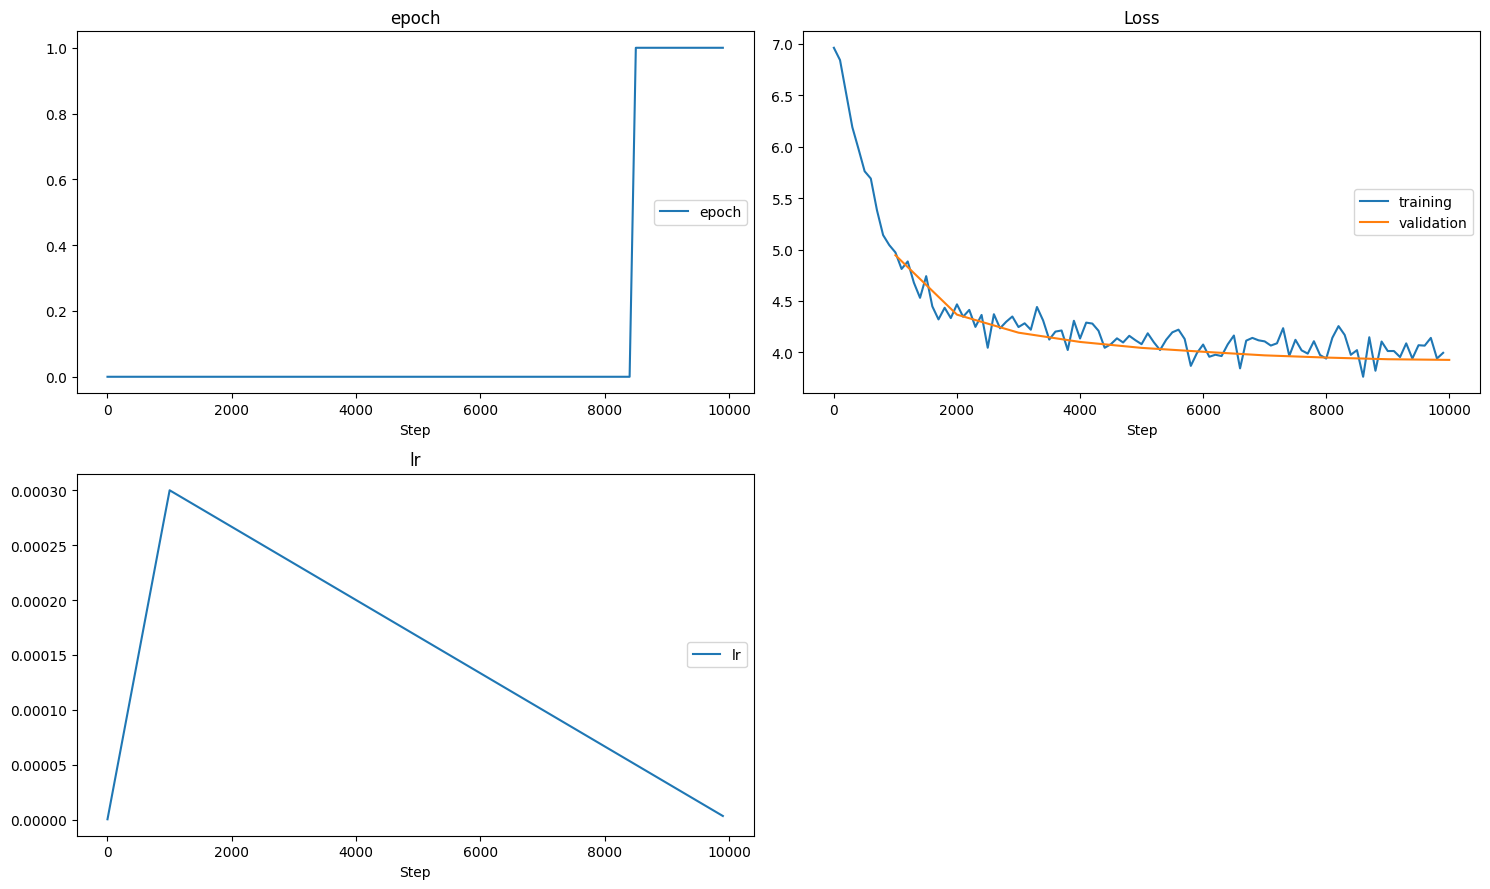

epoch
	epoch            	 (min:    0.000, max:    1.000, cur:    1.000)
Loss
	training         	 (min:    3.762, max:    6.962, cur:    3.995)
	validation       	 (min:    3.926, max:    4.945, cur:    3.926)
lr
	lr               	 (min:    0.000, max:    0.000, cur:    0.000)


In [ ]:
trainer.run(model, train_dataloader, test_dataloader)

In [73]:
# Смотрим на качество генерации глазами
# Для маленьких и слабых моделей "затягиваем" гайки генерации

text = "Заходит в бар"
input_ids = torch.tensor(tokenizer.encode(text)[:-1], device=trainer.device)[None, :]
print(input_ids)
model_output = model.generate(
    input_ids, max_new_tokens=200, eos_token_id=tokenizer.eos_token_id, do_sample=True, top_k=10
)
tokenizer.decode(model_output[0].tolist())

tensor([[717, 258, 618, 275, 302, 338]], device='cuda:0')


'Заходит в баркий. Продходил, американка:\n - Да, с ну, что вчера?\n - Да вот, наконец-тра, что выбралась настели\n - Все, а ты весь?\n Первый год.\n '

In [ ]:
# Загружаем модель на хаб
model.push_to_hub(REPO_NAME)

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...rse-hw1/model.safetensors:  34%|###4      |  573kB / 1.66MB            

CommitInfo(commit_url='https://huggingface.co/tibffc/llm-course-hw1/commit/c2ad408cbe65c2f7dd70185c2a44ec4f356e88ed', commit_message='Push model using huggingface_hub.', commit_description='', oid='c2ad408cbe65c2f7dd70185c2a44ec4f356e88ed', pr_url=None, repo_url=RepoUrl('https://huggingface.co/tibffc/llm-course-hw1', endpoint='https://huggingface.co', repo_type='model', repo_id='tibffc/llm-course-hw1'), pr_revision=None, pr_num=None)